# Оценка качества датасетов

Ноутбук выполняет комплексный анализ качества подготовленных датасетов
и выявляет потенциальные проблемы перед обучением моделей.

Анализируемые аспекты:
- распределение классов (ham / spam)
- длины текстов по классам
- валидность числовых признаков и мультиколлинеарность
- выбросы в числовых признаках (метод IQR)
- дрейф распределений между train и test (KS-тест, PSI)
- анализ словаря (уникальные слова, топ-слова, OOV)
- итоговый отчёт с описанием найденных проблем

Этот блокнот анализирует подготовленные датасеты (`preprocessed.csv` и `test_preprocessed.csv`)
и выявляет потенциальные проблемы после пайплайна подготовки данных.

Проверки дубликатов, конфликтных меток, пустых текстов и пересечений train/test
выполнены в ноутбуках `01_data_preparation` и здесь не повторяются.

Используются библиотеки `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`.

## Импорт необходимых библиотек

In [1]:
import os
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.config import PROCESSED_DIR

## 1. Загрузка данных

Загружаются:
- `preprocessed.csv` — обработанный тренировочный датасет
- `test_preprocessed.csv` — обработанный тестовый датасет

In [2]:
df_train = pd.read_csv(PROCESSED_DIR / 'preprocessed.csv')
df_test = pd.read_csv(PROCESSED_DIR / 'test_preprocessed.csv')
print(f'Train: {len(df_train)} записей')
print(f'Test:  {len(df_test)} записей')

Train: 77523 записей
Test:  41369 записей


## 2. Распределение классов

Для каждого набора (тренировочный, тестовый) выводится:
- количество записей по классам (ham / spam)
- процентное соотношение
- соотношение spam/ham
- столбчатая диаграмма распределения

In [3]:
for _name, _df in [('Тренировочный', df_train), ('Тестовый', df_test)]:
    _ham = len(_df[_df['label'] == 0])
    _spam = len(_df[_df['label'] == 1])
    _total = len(_df)
    _ratio = _spam / _ham if _ham > 0 else float('inf')
    print(f'{_name} набор ({_total} записей):')
    print(f'  Ham (0):  {_ham:>6} ({_ham / _total * 100:.1f}%)')
    print(f'  Spam (1): {_spam:>6} ({_spam / _total * 100:.1f}%)')
    print(f'  Соотношение spam/ham: {_ratio:.2f}')
    print()

Тренировочный набор (77523 записей):
  Ham (0):   59086 (76.2%)
  Spam (1):  18437 (23.8%)
  Соотношение spam/ham: 0.31

Тестовый набор (41369 записей):
  Ham (0):   22625 (54.7%)
  Spam (1):  18744 (45.3%)
  Соотношение spam/ham: 0.83



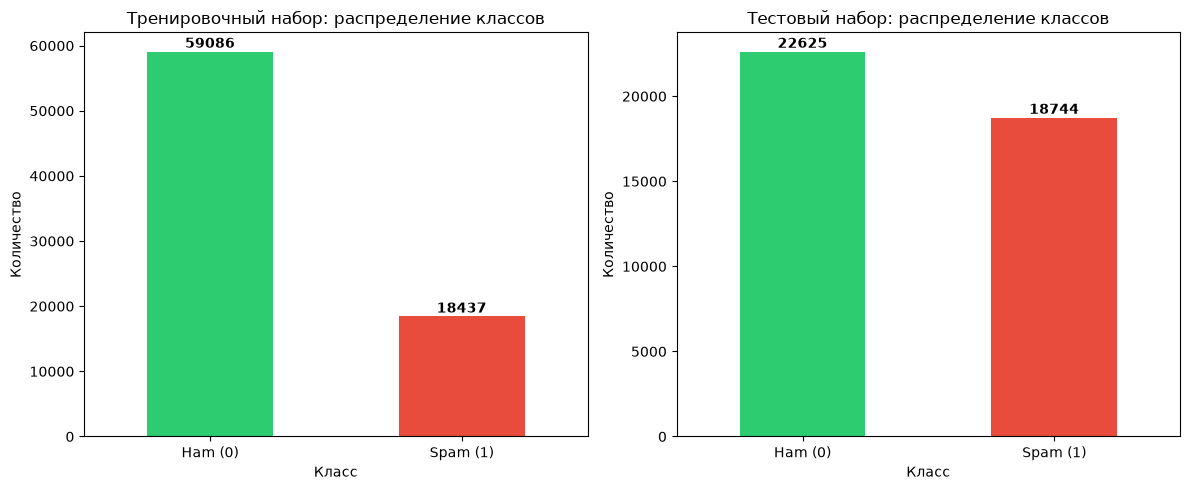

In [4]:
_fig, _axes = plt.subplots(1, 2, figsize=(12, 5))
for _idx, (_name, _df) in enumerate([('Тренировочный', df_train), ('Тестовый', df_test)]):
    counts = _df['label'].value_counts().reindex([0, 1], fill_value=0)
    counts.plot(kind='bar', ax=_axes[_idx], color=['#2ecc71', '#e74c3c'])
    _axes[_idx].set_title(f'{_name} набор: распределение классов')
    _axes[_idx].set_xlabel('Класс')
    _axes[_idx].set_ylabel('Количество')
    _axes[_idx].set_xticks([0, 1])
    _axes[_idx].set_xticklabels(['Ham (0)', 'Spam (1)'], rotation=0)
    ymax = max(counts.max(), 1)
    for _i, v in enumerate(counts):
        _axes[_idx].text(_i, v + ymax * 0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Анализ длин текстов

Для каждого набора и класса выводится:
- минимальная, максимальная, средняя, медианная длина текста
- стандартное отклонение
- гистограмма распределения длин с медианой

In [5]:
for _name, _df in [('Тренировочный', df_train), ('Тестовый', df_test)]:
    _df_copy = _df.copy()
    _df_copy['text_length'] = _df_copy['text'].str.len()
    print(f'{_name} набор:')
    for _label, _label_name in [(0, 'Ham'), (1, 'Spam')]:
        _subset = _df_copy[_df_copy['label'] == _label]['text_length']
        if _subset.empty:
            continue
        print(f'  {_label_name}:')
        print(f'    min={_subset.min()}, max={_subset.max()}, mean={_subset.mean():.1f}, median={_subset.median():.1f}, std={_subset.std():.1f}')
    print()

Тренировочный набор:
  Ham:
    min=5, max=3983, mean=162.4, median=56.0, std=281.4
  Spam:
    min=9, max=4110, mean=326.9, median=198.0, std=372.3

Тестовый набор:
  Ham:
    min=1, max=1712, mean=88.4, median=67.0, std=88.9
  Spam:
    min=2, max=4096, mean=280.2, median=203.0, std=315.0



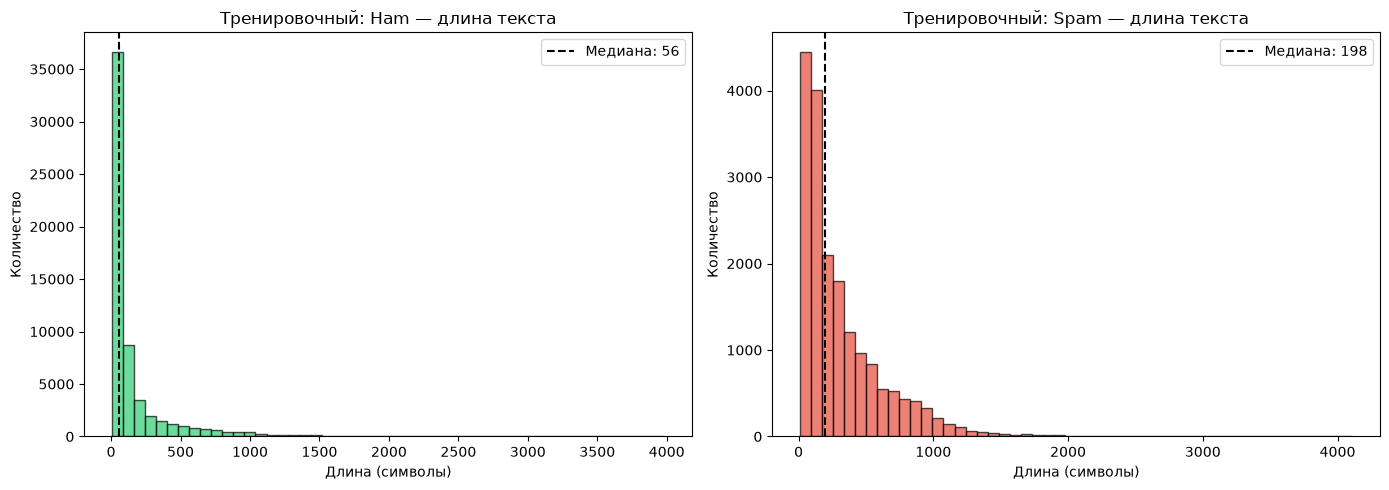

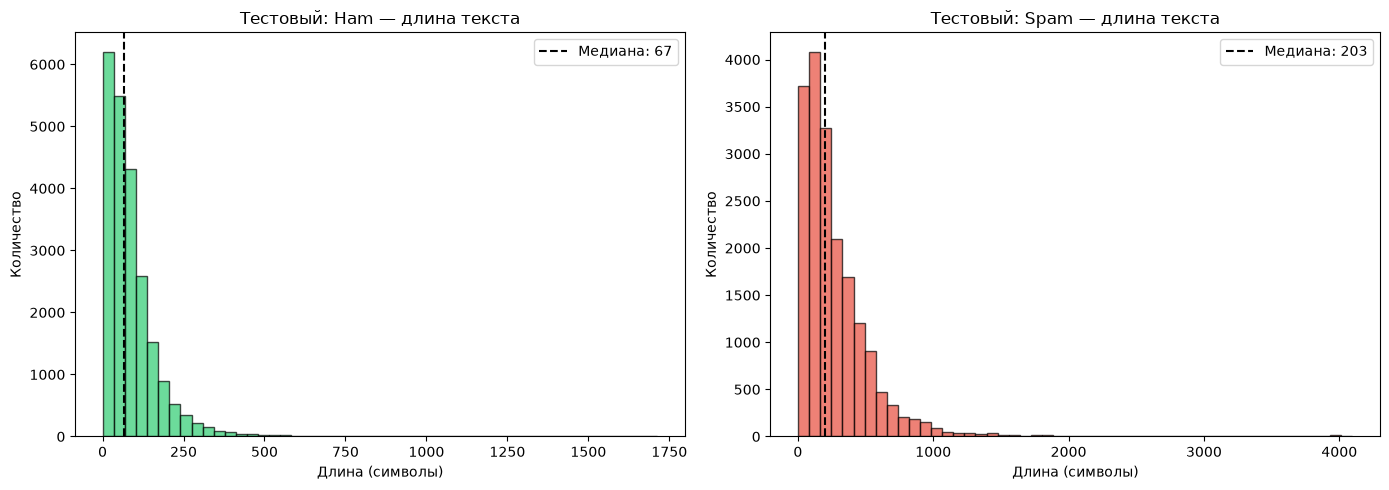

In [6]:
for _name, _df in [('Тренировочный', df_train), ('Тестовый', df_test)]:
    _df_copy = _df.copy()
    _df_copy['text_length'] = _df_copy['text'].str.len()
    _labels_present = [(0, 'Ham', '#2ecc71'), (1, 'Spam', '#e74c3c')]
    _labels_present = [x for x in _labels_present if not _df_copy[_df_copy['label'] == x[0]].empty]
    _n = len(_labels_present)
    if _n == 0:
        continue
    _fig, _axes = plt.subplots(1, _n, figsize=(7 * _n, 5), squeeze=False)
    for _idx, (_label, _label_name, color) in enumerate(_labels_present):
        _subset = _df_copy[_df_copy['label'] == _label]['text_length']
        _axes[0][_idx].hist(_subset, bins=50, color=color, alpha=0.7, edgecolor='black')
        _axes[0][_idx].set_title(f'{_name}: {_label_name} — длина текста')
        _axes[0][_idx].set_xlabel('Длина (символы)')
        _axes[0][_idx].set_ylabel('Количество')
        _axes[0][_idx].axvline(_subset.median(), color='black', linestyle='--', label=f'Медиана: {_subset.median():.0f}')
        _axes[0][_idx].legend()
    plt.tight_layout()
    plt.show()

## 4. Валидность числовых признаков и мультиколлинеарность

Проверка корректности значений числовых признаков:
- отсутствие NaN в числовых колонках
- диапазоны ratio-признаков (capital_ratio, unique_word_ratio, repeat_char_ratio, url_ratio) в [0, 1]
- бинарные признаки (has_crypto, has_markdown) содержат только 0 или 1
- length >= 0

Поиск пар признаков с сильной корреляцией (> 0.8) — мультиколлинеарность,
которая может ухудшить интерпретируемость и стабильность линейных моделей.

In [7]:
_numeric_cols = [
    'emojis', 'newlines', 'whitespaces', 'links', 'tags', 'length',
    'capital_ratio', 'punctuation_count', 'digit_count', 'avg_word_length',
    'word_count', 'unique_word_ratio', 'repeat_char_ratio', 'phone_count',
    'has_crypto', 'exclamation_count', 'url_ratio', 'html_tag_count',
    'has_markdown', 'emoji_diversity',
]

In [8]:
_ratio_cols = ['capital_ratio', 'unique_word_ratio', 'repeat_char_ratio', 'url_ratio']
_binary_cols = ['has_crypto', 'has_markdown']

In [9]:
print('Валидность числовых признаков')
print()

for _name, _df in [('Тренировочный', df_train), ('Тестовый', df_test)]:
    print(f'{_name} набор:')
    
    # NaN проверка
    nan_counts = _df[_numeric_cols].isna().sum()
    nan_found = nan_counts[nan_counts > 0]
    if len(nan_found) > 0:
        print(f'  NaN найдены в колонках:')
        for col, cnt in nan_found.items():
            print(f'    {col}: {cnt}')
    else:
        print(f'  NaN: не найдены')
    
    # Проверка диапазонов ratio
    for col in _ratio_cols:
        if col in _df.columns:
            _min = _df[col].min()
            _max = _df[col].max()
            _violations = ((_df[col] < 0) | (_df[col] > 1)).sum()
            status = 'OK' if _violations == 0 else f'НАРУШЕНИЕ: {_violations} значений вне [0, 1]'
            print(f'  {col:>20}: min={_min:.4f}, max={_max:.4f} — {status}')
    
    # Проверка бинарных признаков
    for col in _binary_cols:
        if col in _df.columns:
            _unique = _df[col].unique()
            _violations = ((~_df[col].isin([0, 1])) & _df[col].notna()).sum()
            status = 'OK' if _violations == 0 else f'НАРУШЕНИЕ: {_violations} значений не 0/1'
            print(f'  {col:>20}: уникальные={sorted(_unique)} — {status}')
    
    # Проверка length
    if 'length' in _df.columns:
        _neg = (_df['length'] < 0).sum()
        status = 'OK' if _neg == 0 else f'НАРУШЕНИЕ: {_neg} отрицательных значений'
        print(f'  {"length":>20}: min={_df["length"].min()} — {status}')
    print()

Валидность числовых признаков

Тренировочный набор:
  NaN: не найдены
         capital_ratio: min=0.0000, max=3.4211 — НАРУШЕНИЕ: 16 значений вне [0, 1]
     unique_word_ratio: min=0.0044, max=1.0000 — OK
     repeat_char_ratio: min=0.0000, max=0.3333 — OK
             url_ratio: min=0.0000, max=1.0000 — OK
            has_crypto: уникальные=[np.int64(0), np.int64(1)] — OK
          has_markdown: уникальные=[np.int64(0), np.int64(1)] — OK
                length: min=5 — OK

Тестовый набор:
  NaN: не найдены
         capital_ratio: min=0.0000, max=1.0149 — НАРУШЕНИЕ: 1 значений вне [0, 1]
     unique_word_ratio: min=0.0276, max=1.0000 — OK
     repeat_char_ratio: min=0.0000, max=0.2500 — OK
             url_ratio: min=0.0000, max=1.0000 — OK
            has_crypto: уникальные=[np.int64(0), np.int64(1)] — OK
          has_markdown: уникальные=[np.int64(0), np.int64(1)] — OK
                length: min=1 — OK



Мультиколлинеарность (|корреляция| > 0.8)

Найдено 4 пар с сильной корреляцией:
                length <-> word_count          : +0.975
              newlines <-> whitespaces         : +0.897
              newlines <-> punctuation_count   : +0.823
                emojis <-> emoji_diversity     : +0.819


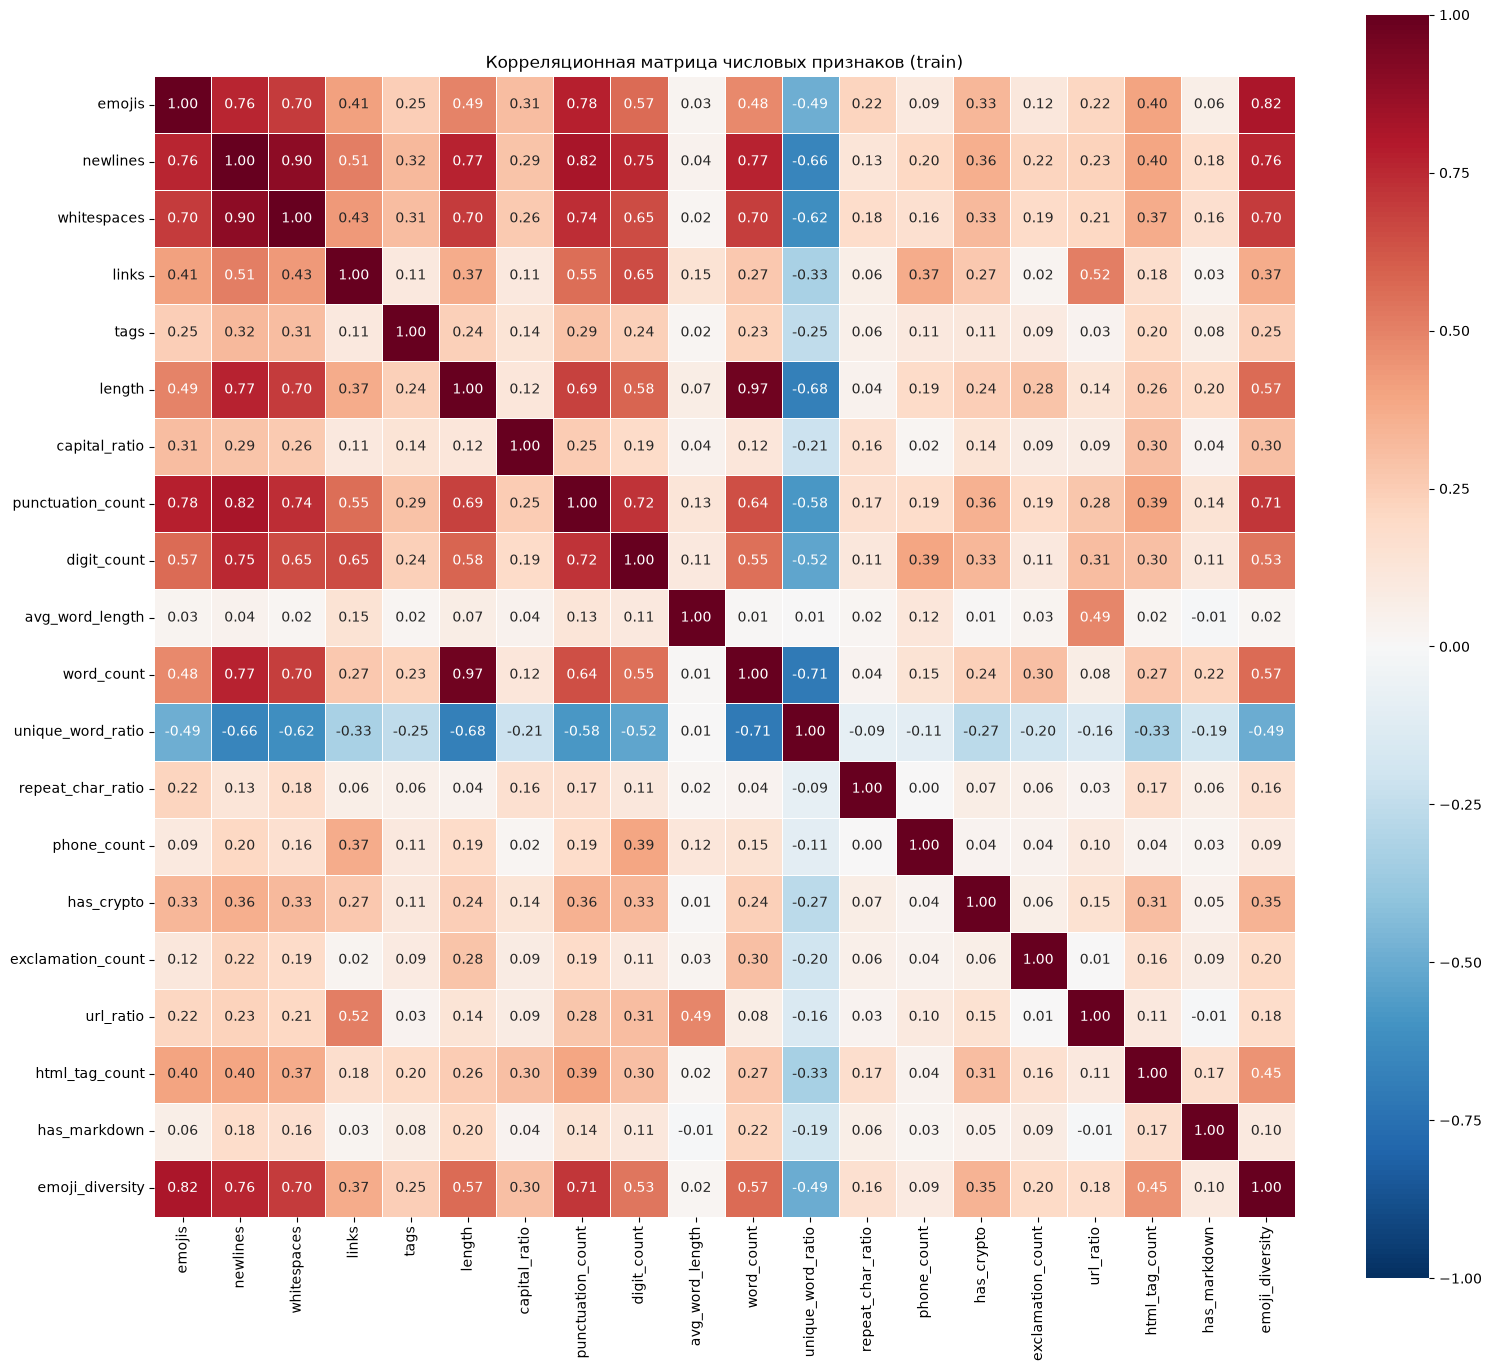

In [10]:
_corr_matrix = df_train[_numeric_cols].corr()

# Поиск пар с корреляцией > 0.8
_high_corr_pairs = []
for i in range(len(_numeric_cols)):
    for j in range(i + 1, len(_numeric_cols)):
        _val = _corr_matrix.iloc[i, j]
        if abs(_val) > 0.8:
            _high_corr_pairs.append((_numeric_cols[i], _numeric_cols[j], _val))

print('Мультиколлинеарность (|корреляция| > 0.8)')
print()
if _high_corr_pairs:
    print(f'Найдено {len(_high_corr_pairs)} пар с сильной корреляцией:')
    for f1, f2, val in sorted(_high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f'  {f1:>20} <-> {f2:<20}: {val:+.3f}')
else:
    print('Пар с сильной корреляцией (> 0.8) не найдено.')

# Тепловая карта корреляций
_fig, _ax = plt.subplots(figsize=(16, 14))
sns.heatmap(_corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=_ax, vmin=-1, vmax=1, linewidths=0.5)
_ax.set_title('Корреляционная матрица числовых признаков (train)')
plt.tight_layout()
plt.show()

## 5. Выбросы в числовых признаках (метод IQR)

Для каждого числового признака определяются выбросы методом IQR:
- нижняя граница: Q1 - 1.5 * IQR
- верхняя граница: Q3 + 1.5 * IQR

Подсчитывается доля выбросов по классам (ham / spam),
чтобы понять, какой класс содержит больше экстремальных значений.

In [11]:
print(f'{"Признак":>20} | {"Всего":>6} | {"% от train":>10} | {"Ham":>6} | {"Spam":>6} | {"% Ham":>7} | {"% Spam":>8}')
print('-' * 85)

_outlier_stats = []
for col in _numeric_cols:
    if col not in df_train.columns:
        continue
    _data = df_train[col]
    _q1 = _data.quantile(0.25)
    _q3 = _data.quantile(0.75)
    _iqr = _q3 - _q1
    _lower = _q1 - 1.5 * _iqr
    _upper = _q3 + 1.5 * _iqr
    _is_outlier = (_data < _lower) | (_data > _upper)
    _total_out = _is_outlier.sum()
    _pct = _total_out / len(df_train) * 100
    
    _ham_mask = df_train['label'] == 0
    _spam_mask = df_train['label'] == 1
    _ham_out = (_is_outlier & _ham_mask).sum()
    _spam_out = (_is_outlier & _spam_mask).sum()
    _ham_pct = _ham_out / _ham_mask.sum() * 100 if _ham_mask.sum() > 0 else 0
    _spam_pct = _spam_out / _spam_mask.sum() * 100 if _spam_mask.sum() > 0 else 0
    
    print(f'{col:>20} | {_total_out:>6} | {_pct:>9.1f}% | {_ham_out:>6} | {_spam_out:>6} | {_ham_pct:>6.1f}% | {_spam_pct:>7.1f}%')
    _outlier_stats.append({'feature': col, 'total': _total_out, 'pct': _pct, 'ham': _ham_out, 'spam': _spam_out})

             Признак |  Всего | % от train |    Ham |   Spam |   % Ham |   % Spam
-------------------------------------------------------------------------------------
              emojis |  14850 |      19.2% |   5819 |   9031 |    9.8% |    49.0%
            newlines |   9488 |      12.2% |   3345 |   6143 |    5.7% |    33.3%
         whitespaces |   8257 |      10.7% |   2730 |   5527 |    4.6% |    30.0%
               links |   8128 |      10.5% |   4884 |   3244 |    8.3% |    17.6%
                tags |   7300 |       9.4% |   1830 |   5470 |    3.1% |    29.7%
              length |   8943 |      11.5% |   5181 |   3762 |    8.8% |    20.4%
       capital_ratio |   7490 |       9.7% |   2125 |   5365 |    3.6% |    29.1%
   punctuation_count |   8539 |      11.0% |   2612 |   5927 |    4.4% |    32.1%
         digit_count |   9642 |      12.4% |   4262 |   5380 |    7.2% |    29.2%
     avg_word_length |   3052 |       3.9% |   2338 |    714 |    4.0% |     3.9%
          wo

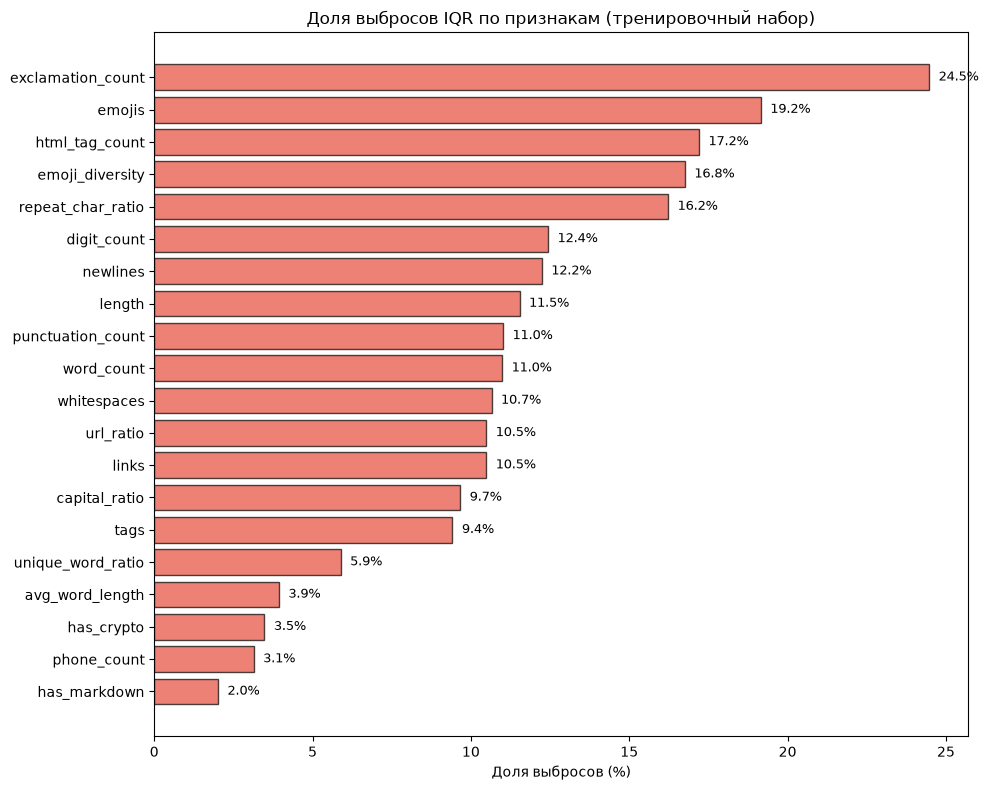

In [12]:
_outlier_df = pd.DataFrame(_outlier_stats)
_outlier_df = _outlier_df.sort_values('pct', ascending=True)

_fig, _ax = plt.subplots(figsize=(10, 8))
_ax.barh(_outlier_df['feature'], _outlier_df['pct'], color='#e74c3c', alpha=0.7, edgecolor='black')
_ax.set_xlabel('Доля выбросов (%)')
_ax.set_title('Доля выбросов IQR по признакам (тренировочный набор)')
for _i, (_val, _name) in enumerate(zip(_outlier_df['pct'], _outlier_df['feature'])):
    _ax.text(_val + 0.3, _i, f'{_val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Дрейф распределений между train и test

Для каждого числового признака вычисляются:
- **KS-тест** (Колмогоров-Смирнов) — проверка гипотезы о равенстве распределений
- **PSI** (Population Stability Index) — индекс стабильности популяции

Интерпретация PSI:
- PSI < 0.1 — распределение стабильное
- 0.1 <= PSI < 0.25 — умеренный дрейф
- PSI >= 0.25 — значительный дрейф

In [13]:
def calculate_psi(expected, actual, bins=10):
    """Вычисление Population Stability Index между двумя распределениями."""
    _eps = 1e-6
    _edges = np.linspace(expected.min(), expected.max(), bins + 1)
    _edges[0] = -np.inf
    _edges[-1] = np.inf
    
    _exp_counts = np.histogram(expected, bins=_edges)[0]
    _act_counts = np.histogram(actual, bins=_edges)[0]
    
    _exp_pct = _exp_counts / len(expected) + _eps
    _act_pct = _act_counts / len(actual) + _eps
    
    _psi = np.sum((_act_pct - _exp_pct) * np.log(_act_pct / _exp_pct))
    return _psi

In [14]:
_drift_results = []
for col in _numeric_cols:
    if col not in df_train.columns or col not in df_test.columns:
        continue
    _train_vals = df_train[col].dropna()
    _test_vals = df_test[col].dropna()
    
    _ks_stat, _ks_pval = ks_2samp(_train_vals, _test_vals)
    _psi = calculate_psi(_train_vals, _test_vals)
    
    if _psi < 0.1:
        _interpretation = 'стабильно'
    elif _psi < 0.25:
        _interpretation = 'умеренный дрейф'
    else:
        _interpretation = 'значительный дрейф'
    
    _drift_results.append({
        'feature': col,
        'ks_stat': _ks_stat,
        'ks_pval': _ks_pval,
        'psi': _psi,
        'interpretation': _interpretation,
    })

_drift_df = pd.DataFrame(_drift_results)

print('Дрейф распределений train vs test')
print()
print(f'{"Признак":>20} | {"KS stat":>8} | {"p-value":>12} | {"PSI":>8} | Интерпретация')
print('-' * 85)
for _, row in _drift_df.sort_values('psi', ascending=False).iterrows():
    _pval_str = f'{row["ks_pval"]:.2e}' if row['ks_pval'] < 0.001 else f'{row["ks_pval"]:.4f}'
    print(f'{row["feature"]:>20} | {row["ks_stat"]:>8.4f} | {_pval_str:>12} | {row["psi"]:>8.4f} | {row["interpretation"]}')

Дрейф распределений train vs test

             Признак |  KS stat |      p-value |      PSI | Интерпретация
-------------------------------------------------------------------------------------
           url_ratio |   0.0689 |    6.09e-112 |   0.0732 | стабильно
          has_crypto |   0.0487 |     4.84e-56 |   0.0452 | стабильно
              length |   0.1162 |    1.37e-317 |   0.0411 | стабильно
          word_count |   0.1087 |    4.29e-278 |   0.0330 | стабильно
   unique_word_ratio |   0.0619 |     2.63e-90 |   0.0167 | стабильно
         digit_count |   0.0469 |     5.80e-52 |   0.0140 | стабильно
            newlines |   0.0751 |    6.60e-133 |   0.0125 | стабильно
      html_tag_count |   0.1674 |     0.00e+00 |   0.0099 | стабильно
     emoji_diversity |   0.0263 |     1.31e-16 |   0.0093 | стабильно
              emojis |   0.0348 |     8.28e-29 |   0.0079 | стабильно
         whitespaces |   0.0708 |    5.90e-118 |   0.0069 | стабильно
               links |   0.0689 |  

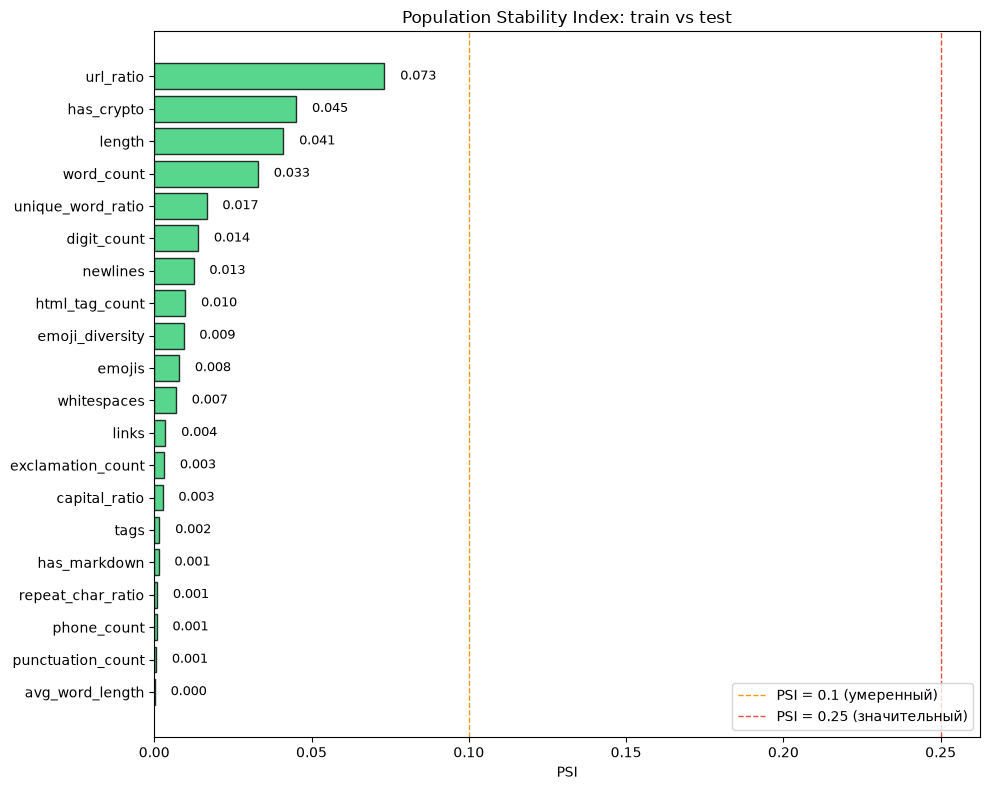

In [15]:
_drift_sorted = _drift_df.sort_values('psi', ascending=True)

_fig, _ax = plt.subplots(figsize=(10, 8))
_colors = ['#2ecc71' if p < 0.1 else '#f39c12' if p < 0.25 else '#e74c3c' for p in _drift_sorted['psi']]
_ax.barh(_drift_sorted['feature'], _drift_sorted['psi'], color=_colors, alpha=0.8, edgecolor='black')
_ax.axvline(0.1, color='#f39c12', linestyle='--', linewidth=1, label='PSI = 0.1 (умеренный)')
_ax.axvline(0.25, color='#e74c3c', linestyle='--', linewidth=1, label='PSI = 0.25 (значительный)')
_ax.set_xlabel('PSI')
_ax.set_title('Population Stability Index: train vs test')
_ax.legend(loc='lower right')
for _i, (_val, _name) in enumerate(zip(_drift_sorted['psi'], _drift_sorted['feature'])):
    _ax.text(_val + 0.005, _i, f'{_val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Гистограммы для топ-4 признаков с наибольшим дрейфом

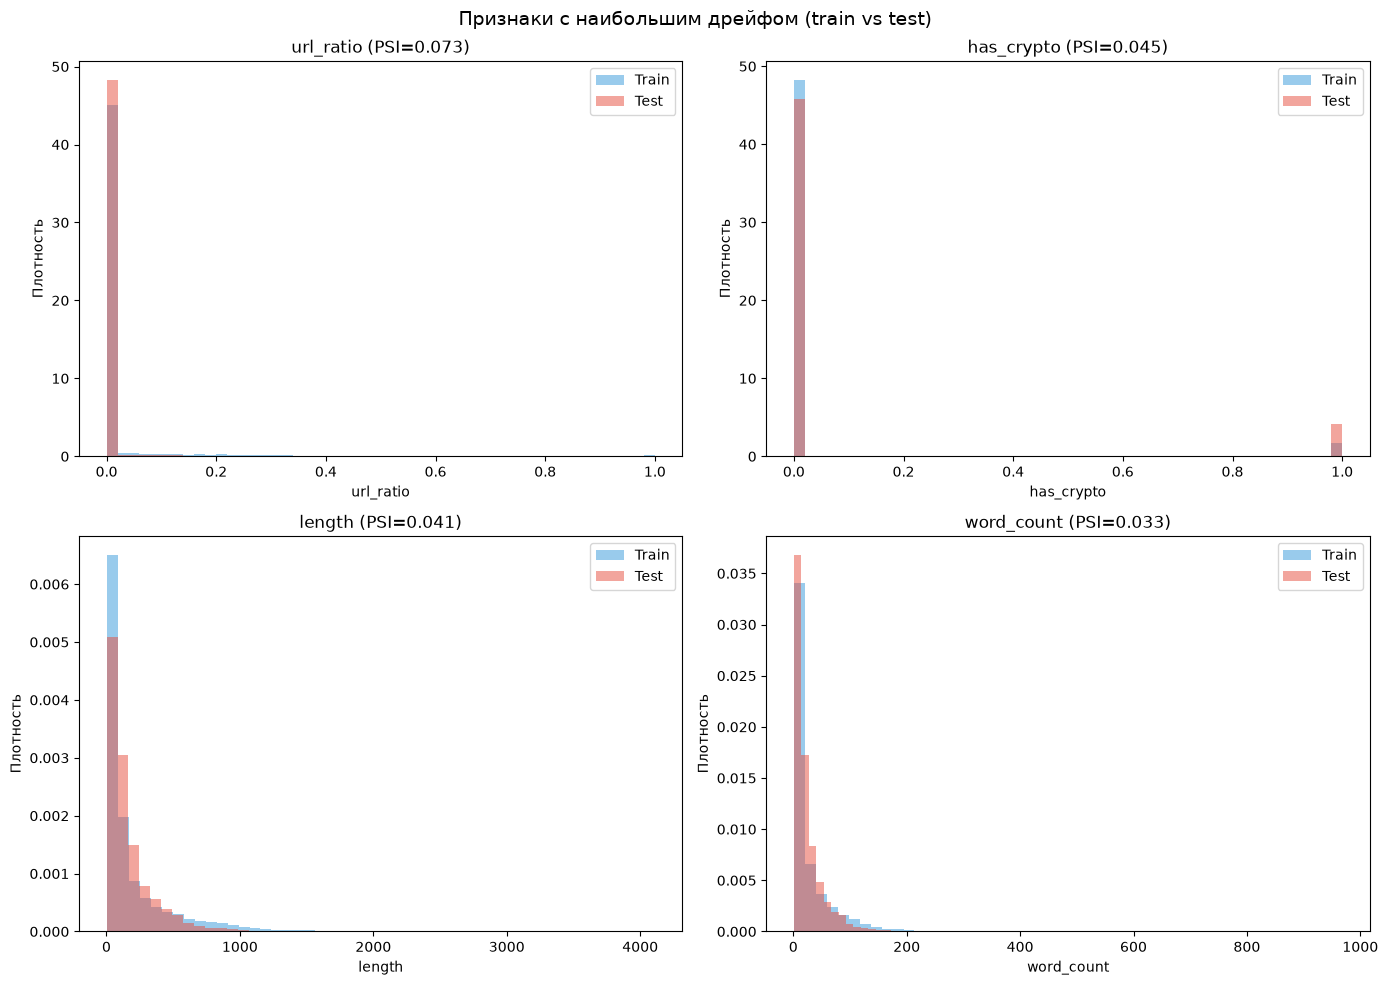

In [16]:
_top_drift = _drift_df.sort_values('psi', ascending=False).head(4)

if len(_top_drift) > 0:
    _fig, _axes = plt.subplots(2, 2, figsize=(14, 10))
    _axes = _axes.flatten()
    for _idx, (_, row) in enumerate(_top_drift.iterrows()):
        col = row['feature']
        _train_vals = df_train[col].dropna()
        _test_vals = df_test[col].dropna()
        _axes[_idx].hist(_train_vals, bins=50, alpha=0.5, color='#3498db', density=True, label='Train')
        _axes[_idx].hist(_test_vals, bins=50, alpha=0.5, color='#e74c3c', density=True, label='Test')
        _axes[_idx].set_title(f'{col} (PSI={row["psi"]:.3f})')
        _axes[_idx].set_xlabel(col)
        _axes[_idx].set_ylabel('Плотность')
        _axes[_idx].legend()
    plt.suptitle('Признаки с наибольшим дрейфом (train vs test)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. Анализ словаря

Анализ словарного состава на основе `text_preprocessed`:
- размер словаря train и test
- топ-20 слов по классам (ham / spam) с частотами
- пересечение словарей ham и spam в train
- OOV-слова в test (слова из test, отсутствующие в train)

In [17]:
def build_vocab(texts):
    """Построение словаря из коллекции текстов."""
    _vocab = Counter()
    for text in texts:
        if isinstance(text, str):
            _vocab.update(text.split())
    return _vocab

In [18]:
_train_ham_vocab = build_vocab(df_train[df_train['label'] == 0]['text_preprocessed'])
_train_spam_vocab = build_vocab(df_train[df_train['label'] == 1]['text_preprocessed'])
_train_all_vocab = _train_ham_vocab + _train_spam_vocab
_test_vocab = build_vocab(df_test['text_preprocessed'])

print('Размер словаря:')
print(f'  Train (всего):     {len(_train_all_vocab):>8} уникальных слов')
print(f'  Train (ham):       {len(_train_ham_vocab):>8} уникальных слов')
print(f'  Train (spam):      {len(_train_spam_vocab):>8} уникальных слов')
print(f'  Test:              {len(_test_vocab):>8} уникальных слов')
print()

Размер словаря:
  Train (всего):       164559 уникальных слов
  Train (ham):          77487 уникальных слов
  Train (spam):        102699 уникальных слов
  Test:                103511 уникальных слов



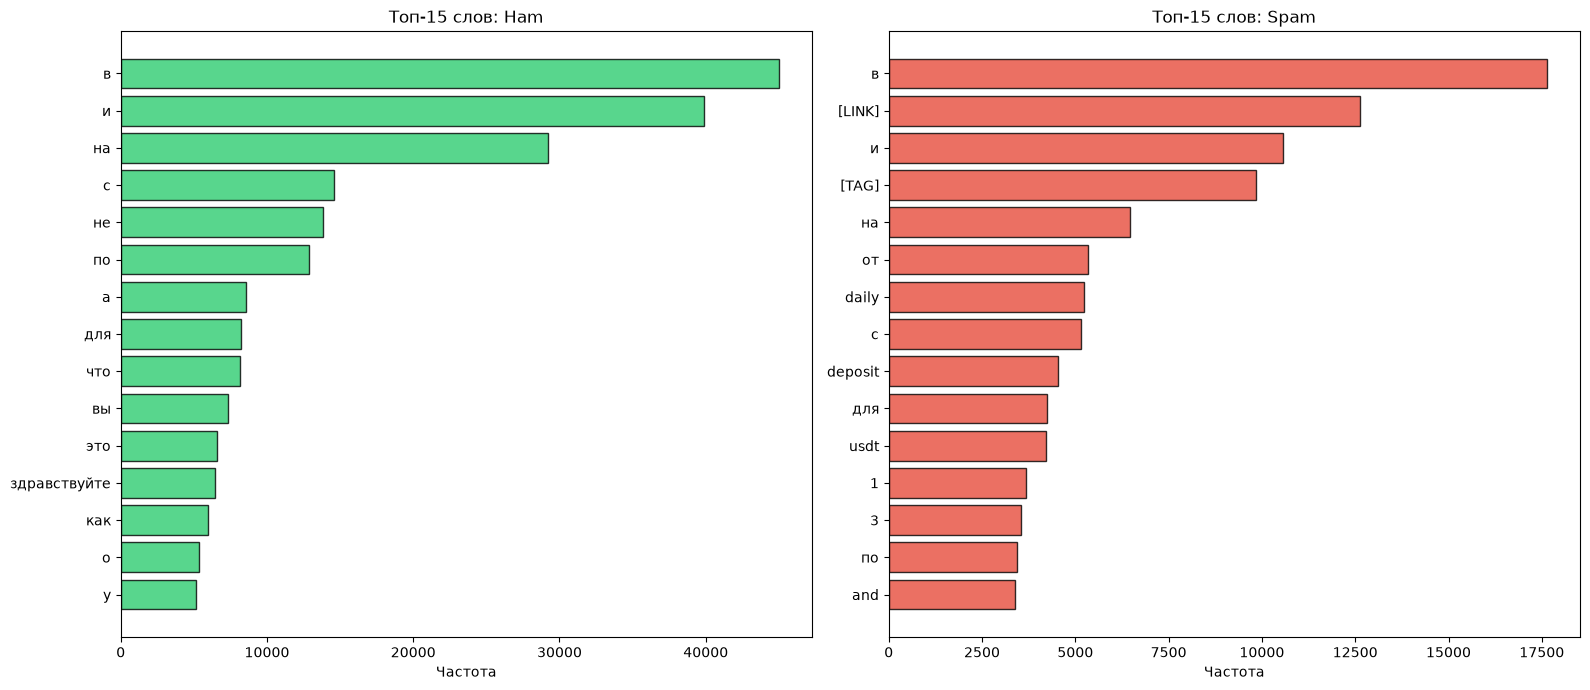

In [19]:
_top_ham = _train_ham_vocab.most_common(15)
_top_spam = _train_spam_vocab.most_common(15)

_fig, _axes = plt.subplots(1, 2, figsize=(16, 7))

_ham_words = [w for w, _ in _top_ham]
_ham_counts = [c for _, c in _top_ham]
_axes[0].barh(_ham_words[::-1], _ham_counts[::-1], color='#2ecc71', alpha=0.8, edgecolor='black')
_axes[0].set_title('Топ-15 слов: Ham')
_axes[0].set_xlabel('Частота')

_spam_words = [w for w, _ in _top_spam]
_spam_counts = [c for _, c in _top_spam]
_axes[1].barh(_spam_words[::-1], _spam_counts[::-1], color='#e74c3c', alpha=0.8, edgecolor='black')
_axes[1].set_title('Топ-15 слов: Spam')
_axes[1].set_xlabel('Частота')

plt.tight_layout()
plt.show()

In [20]:
_overlap = set(_train_ham_vocab.keys()) & set(_train_spam_vocab.keys())
_ham_only = set(_train_ham_vocab.keys()) - _overlap
_spam_only = set(_train_spam_vocab.keys()) - _overlap
print(f'Пересечение словарей ham/spam в train')
print(f'  Общих слов:        {len(_overlap):>8}')
print(f'  Только в ham:      {len(_ham_only):>8}')
print(f'  Только в spam:     {len(_spam_only):>8}')
print()

Пересечение словарей ham/spam в train
  Общих слов:           15627
  Только в ham:         61860
  Только в spam:        87072



In [21]:
_test_oov = set(_test_vocab.keys()) - set(_train_all_vocab.keys())
_oov_ratio = len(_test_oov) / len(_test_vocab) * 100 if len(_test_vocab) > 0 else 0
print(f'OOV слова в test')
print(f'  Всего слов в test:  {len(_test_vocab):>8}')
print(f'  OOV (нет в train):  {len(_test_oov):>8} ({_oov_ratio:.1f}%)')
print()

OOV слова в test
  Всего слов в test:    103511
  OOV (нет в train):     62290 (60.2%)



In [22]:
print('Топ-20 слов (ham):')
for word, count in _train_ham_vocab.most_common(20):
    print(f'  {word:>20}: {count:>6}')
print()
print('Топ-20 слов (spam):')
for word, count in _train_spam_vocab.most_common(20):
    print(f'  {word:>20}: {count:>6}')

Топ-20 слов (ham):
                     в:  45014
                     и:  39899
                    на:  29245
                     с:  14569
                    не:  13860
                    по:  12893
                     а:   8588
                   для:   8226
                   что:   8145
                    вы:   7322
                   это:   6571
          здравствуйте:   6418
                   как:   5999
                     о:   5363
                     у:   5181
                  если:   5110
                    мы:   4973
                     к:   4885
                     я:   4855
                    до:   4685

Топ-20 слов (spam):
                     в:  17641
                [LINK]:  12631
                     и:  10556
                 [TAG]:   9854
                    на:   6458
                    от:   5328
                 daily:   5236
                     с:   5155
               deposit:   4546
                   для:   4229
                  usdt:   4223

## 8. Итоговый отчёт

Автоматическая проверка основных проблем:
- дисбаланс классов (соотношение > 2x)
- NaN в числовых признаках
- нарушение диапазонов ratio-признаков
- мультиколлинеарность (|корреляция| > 0.8)
- значительный дрейф распределений (PSI >= 0.25)
- высокая доля OOV-слов в тесте (> 30%)

In [23]:
issues = []

Дисбаланс классов

In [24]:
for _name, _df in [('Тренировочный', df_train), ('Тестовый', df_test)]:
    _ham = len(_df[_df['label'] == 0])
    _spam = len(_df[_df['label'] == 1])
    if _ham > 0 and _spam > 0:
        _ratio = max(_ham, _spam) / min(_ham, _spam)
        if _ratio > 2:
            issues.append(f'{_name}: сильный дисбаланс классов — {_ratio:.1f}x')

NaN в числовых признаках

In [25]:
for _name, _df in [('Тренировочный', df_train), ('Тестовый', df_test)]:
    _nan = _df[_numeric_cols].isna().sum().sum()
    if _nan > 0:
        issues.append(f'{_name}: NaN в числовых признаках — {_nan}')

Нарушение диапазонов ratio

In [26]:
for _name, _df in [('Тренировочный', df_train), ('Тестовый', df_test)]:
    for col in _ratio_cols:
        if col in _df.columns:
            _violations = ((_df[col] < 0) | (_df[col] > 1)).sum()
            if _violations > 0:
                issues.append(f'{_name}: {col} — {_violations} значений вне [0, 1]')

Мультиколлинеарность

In [27]:
if _high_corr_pairs:
    issues.append(f'Мультиколлинеарность: {len(_high_corr_pairs)} пар с |корреляцией| > 0.8')

Дрейф распределений

In [28]:
_high_drift = _drift_df[_drift_df['psi'] >= 0.25]
if len(_high_drift) > 0:
    _drift_features = ', '.join(_high_drift['feature'].tolist())
    issues.append(f'Значительный дрейф (PSI >= 0.25): {_drift_features}')

OOV в тесте

In [29]:
if _oov_ratio > 30:
    issues.append(f'Высокая доля OOV-слов в тесте: {_oov_ratio:.1f}%')

Вывод

In [30]:
if issues:
    print('Обнаруженные проблемы:')
    for _i, issue in enumerate(issues, 1):
        print(f'  {_i}. {issue}')
else:
    print('Серьёзных проблем не обнаружено.')

Обнаруженные проблемы:
  1. Тренировочный: сильный дисбаланс классов — 3.2x
  2. Тренировочный: capital_ratio — 16 значений вне [0, 1]
  3. Тестовый: capital_ratio — 1 значений вне [0, 1]
  4. Мультиколлинеарность: 4 пар с |корреляцией| > 0.8
  5. Высокая доля OOV-слов в тесте: 60.2%
